In [ ]:
import os

import ChessLens
from OcclusionDetection import OcclusionDetectionCNN
from WakeupDetection import WakeupModule

import matplotlib.pyplot as plt
import torch

from tqdm import tqdm

game_dir = "/mnt/D/University/Thesis_Dataset/Temp/video_2/video_14"
model_occlusion = OcclusionDetectionCNN.OcclusionDetectorCNN()
model = WakeupModule.WakeupModule()

out = []

for subdir, _, files in os.walk(game_dir):
    for file in tqdm(files):
        if not (file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg")):
            continue

        img = ChessLens.ChessLensImage(os.path.join(subdir, file))
        img.detect_board()
        warped, _ = img.warp()

        model_occlusion.set_img((torch.from_numpy(warped).permute(
            2, 0, 1).unsqueeze(0).float() / 255.0).to("cuda"))
        is_hand = model_occlusion.is_occluded()[0]

        if not is_hand:
            res = model.is_wakeup(warped)

        out.append(f"{file} | {"Occlusion" if is_hand else ("Wakeup" if res else "Sleep")}")

out = "\n".join(out)
with open("out/labels.txt", "w") as f:
    f.write(out)

  0%|          | 0/593 [00:00<?, ?it/s]

100%|██████████| 593/593 [02:55<00:00,  3.37it/s]


ValueError: invalid mode: 'W'

In [14]:
vals = [(int(line.split("|")[0].strip("game_").strip(".jpg ")), line) for line in out.split("\n")]

vals.sort()

vals

[(0, 'game_0.jpg | Wakeup'),
 (1, 'game_1.jpg | Wakeup'),
 (2, 'game_2.jpg | Wakeup'),
 (3, 'game_3.jpg | Wakeup'),
 (4, 'game_4.jpg | Wakeup'),
 (5, 'game_5.jpg | Wakeup'),
 (6, 'game_6.jpg | Wakeup'),
 (7, 'game_7.jpg | Wakeup'),
 (8, 'game_8.jpg | Wakeup'),
 (9, 'game_9.jpg | Wakeup'),
 (10, 'game_10.jpg | Occlusion'),
 (11, 'game_11.jpg | Wakeup'),
 (12, 'game_12.jpg | Wakeup'),
 (13, 'game_13.jpg | Wakeup'),
 (14, 'game_14.jpg | Wakeup'),
 (15, 'game_15.jpg | Occlusion'),
 (16, 'game_16.jpg | Occlusion'),
 (17, 'game_17.jpg | Wakeup'),
 (18, 'game_18.jpg | Wakeup'),
 (19, 'game_19.jpg | Wakeup'),
 (20, 'game_20.jpg | Wakeup'),
 (21, 'game_21.jpg | Wakeup'),
 (22, 'game_22.jpg | Wakeup'),
 (23, 'game_23.jpg | Occlusion'),
 (24, 'game_24.jpg | Wakeup'),
 (25, 'game_25.jpg | Wakeup'),
 (26, 'game_26.jpg | Occlusion'),
 (27, 'game_27.jpg | Wakeup'),
 (28, 'game_28.jpg | Wakeup'),
 (29, 'game_29.jpg | Wakeup'),
 (30, 'game_30.jpg | Wakeup'),
 (31, 'game_31.jpg | Occlusion'),
 (32, 'gam

In [17]:
with open("out/labels.txt", "w") as f:
    f.write("\n".join([val[1] for val in vals]))

In [19]:
i = 0

51 Wakeup


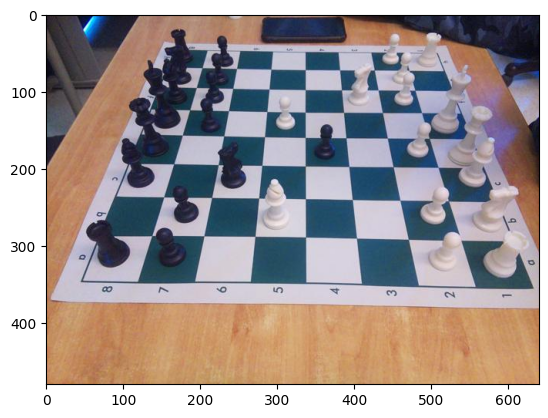

In [72]:
val = vals[i]
index, line = val
pred = line.split(" | ")[1]
file_path = os.path.join(game_dir, f"game_{index}.jpg")

img = plt.imread(file_path)
plt.imshow(img);
print(i, pred)

i += 1